# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root for gates
os.chdir(os.path.abspath(".."))  # data/ paths resolve from project root
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import random

In [2]:
from gates.plotting import plot_fp_predictions

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd


In [4]:
from gates.data.load_data import load_flux_data, cut_flux_data
from gates.evaluation.post_processing import threshold_fps
import gates.evaluation.metrics as gates_metrics

## across region

579


/mnt/shared/home/kr21883/GATES_LPDM_emulator/gates/plotting/plotting_predictions.py:516: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


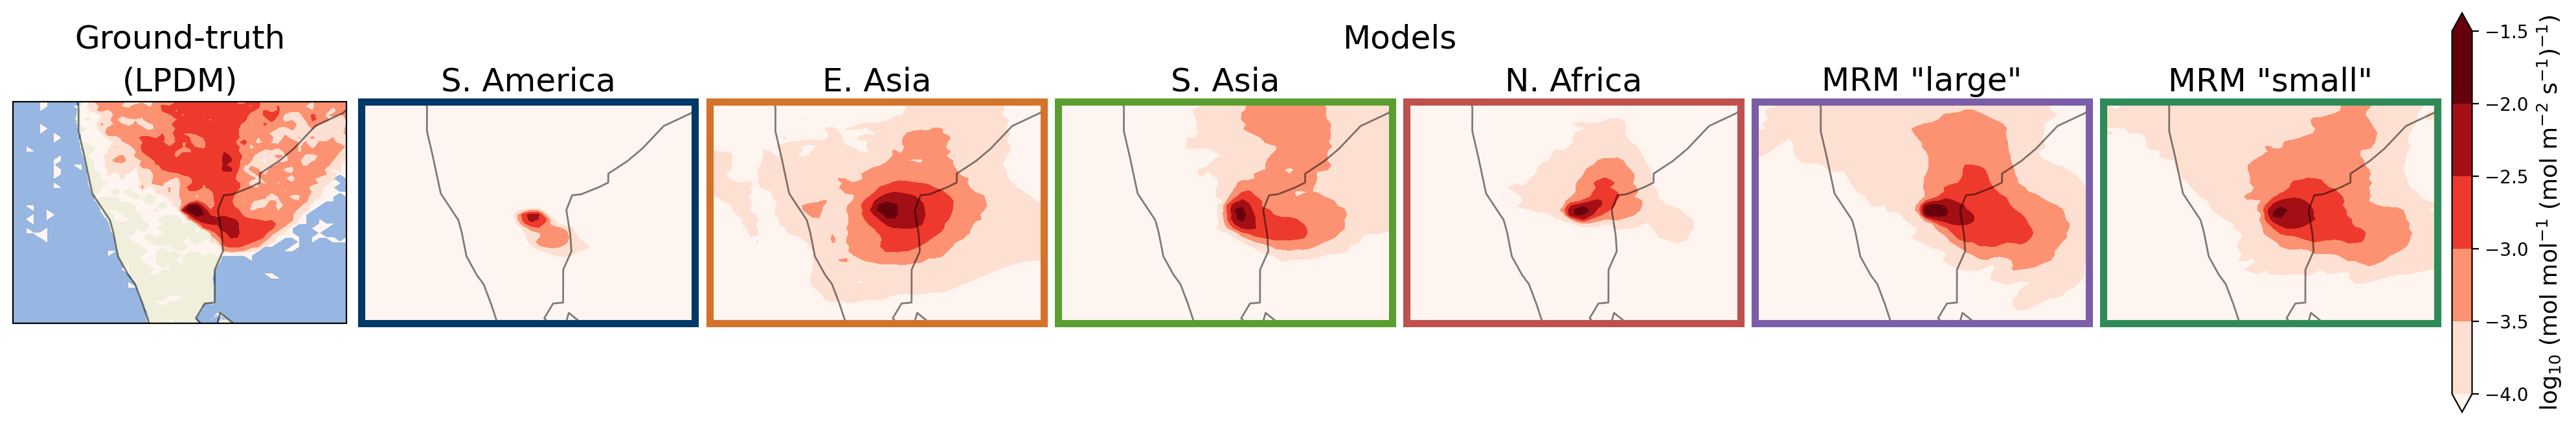

In [8]:
from gates.plotting import plot_multi_model_predictions

test_region = "INDIA"
index_to_plot = random.randint(0, 10000)
index_to_plot = 579
print(index_to_plot)

# sahara 7416
# brazil 3026
# china 3348
# india 579



fig, ax = plot_multi_model_predictions(
    test_region=test_region,
    idx=index_to_plot,
    fig_title=False,
    save=True,
    filename=f"{test_region.lower()}_all_models_plus_small_multiregion_idx{index_to_plot}_300dpi_update_title_341.png",
    fontsize=18,
    legend_fontsize=13,
    title_layout="grouped",
    model_group_title="Models",
    truth_panel_title="Ground-truth",
    truth_panel_label="(LPDM)",
)

In [83]:
def plot_regional_fps(model_region, test_region, idxs_list=None, contour=True, thres=1e-4):
    if model_region == "MULTI_REGION":
        pred_dir = f"model_test_predictions/{model_region.lower()}_model/sahara_india_china_brazil_multiregion_proper/predictions_{test_region}"
    elif model_region != "INDIA":
        pred_dir = f"model_test_predictions/{model_region.lower()}_model/{model_region}_proper/predictions_{test_region}"
    else:
        pred_dir = f"model_test_predictions/{model_region.lower()}_model/{model_region}_proper_train_freq_2_test_freq_25/predictions_{test_region}"
    print(pred_dir)
    preds = xr.open_mfdataset(glob.glob(f"/mnt/shared/home/kr21883/GATES_LPDM_emulator/{pred_dir}/predictions_2014_*.nc"))
    preds = threshold_fps(preds, threshold=1.75e-5)
    if idxs_list is None:
        ints_to_plot = random.sample(list(range(len(preds.time.values))), 4)
    else:        ints_to_plot = [10, 100, 200, 240]
    print(ints_to_plot)
    plot_fp_predictions(preds, idxs_list=ints_to_plot, contour=contour, thres=thres, fig_title=f"{test_region} footprints predicted with a {model_region}-trained model", which_dataspace="original")

model_test_predictions/brazil_model/BRAZIL_proper/predictions_BRAZIL
[16007, 14483, 7661, 16354]
[1, 1]


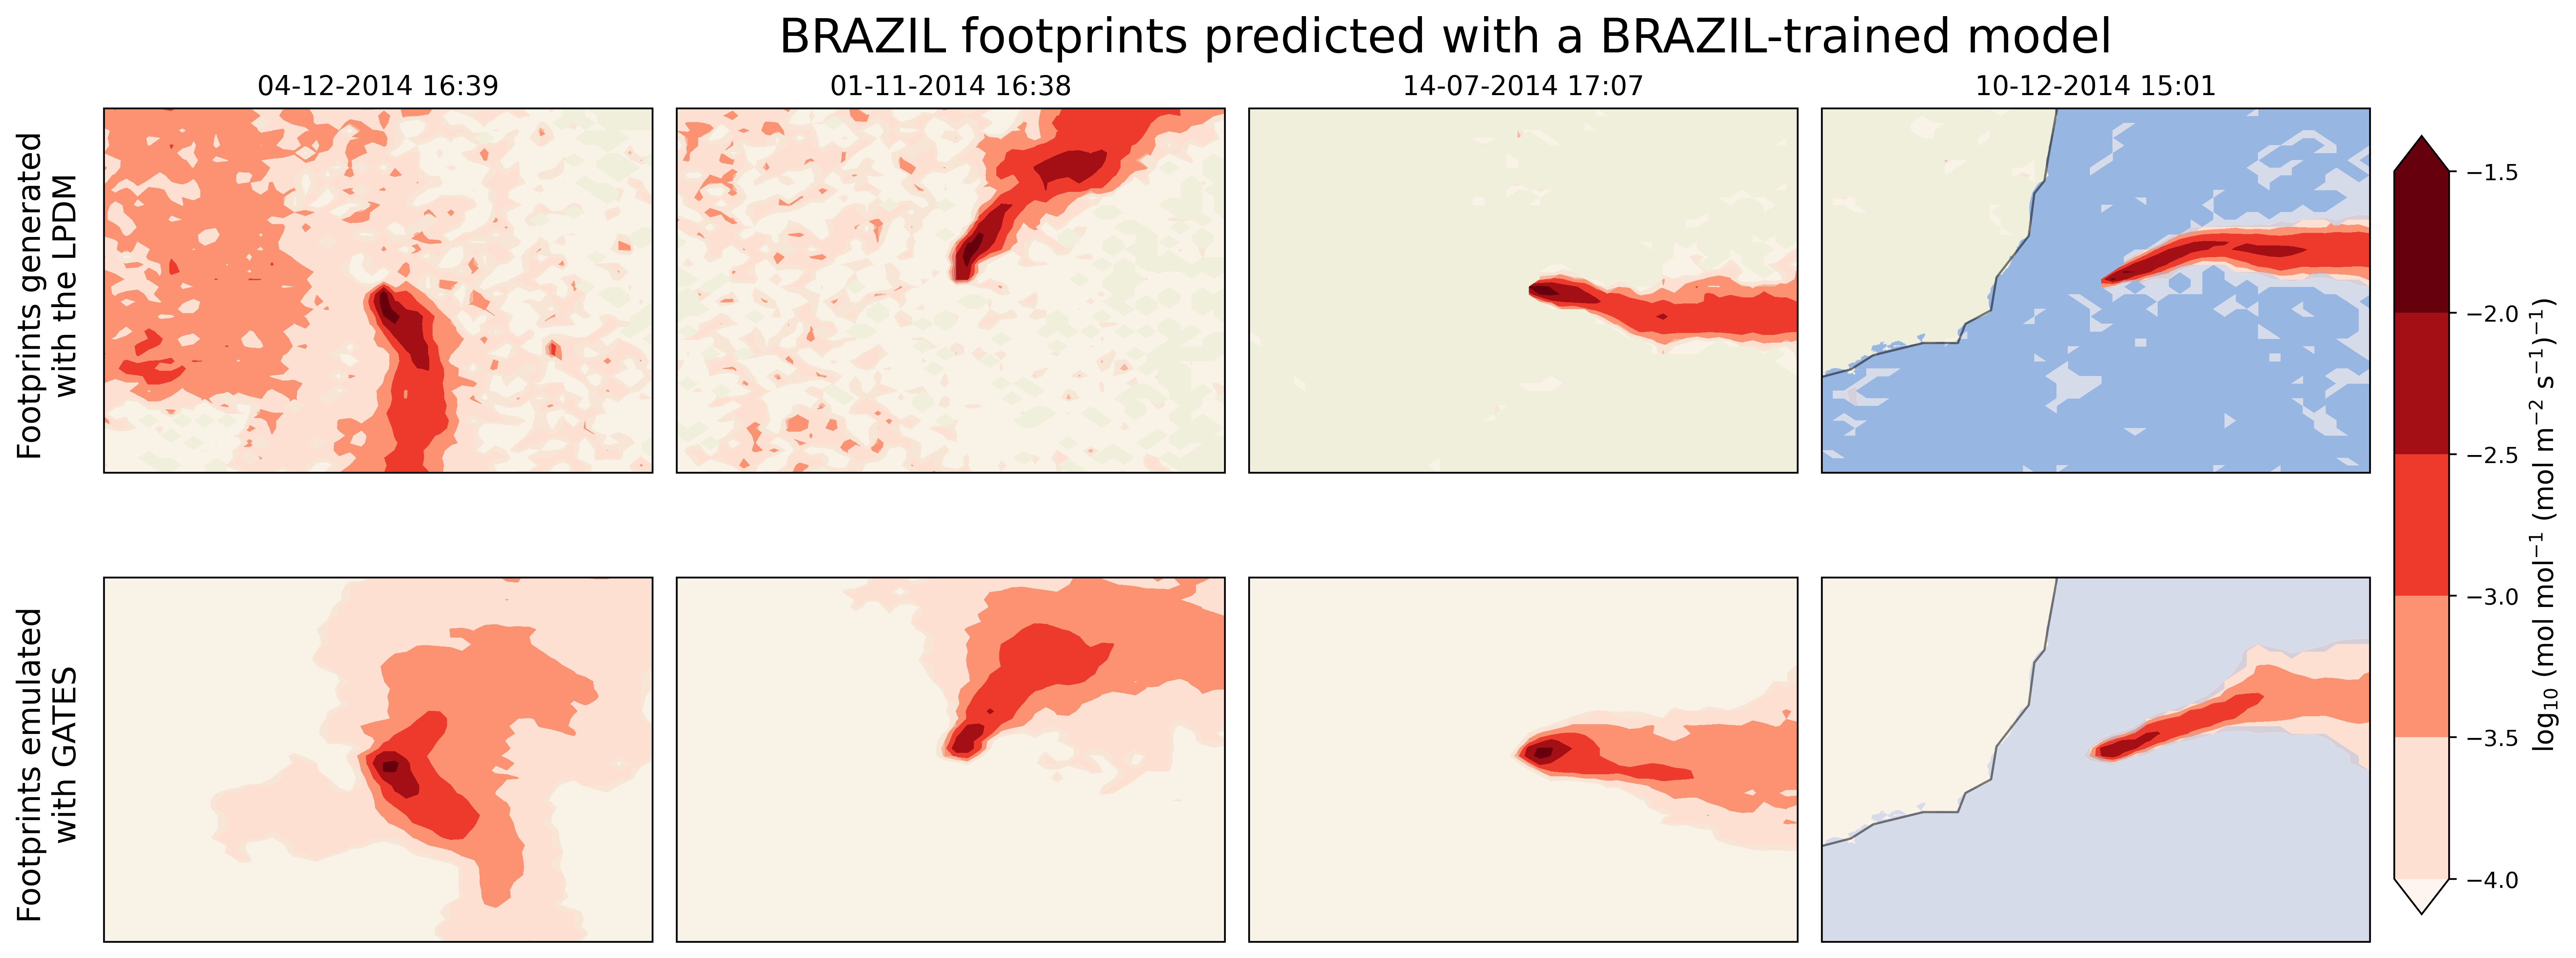

In [20]:
plot_regional_fps("BRAZIL", "BRAZIL", #idxs_list=index_to_plot
    )

model_test_predictions/multi_region_model/sahara_india_china_brazil_multiregion_proper/predictions_SAHARA
[8616, 10302, 7051, 1757]
[1, 1]


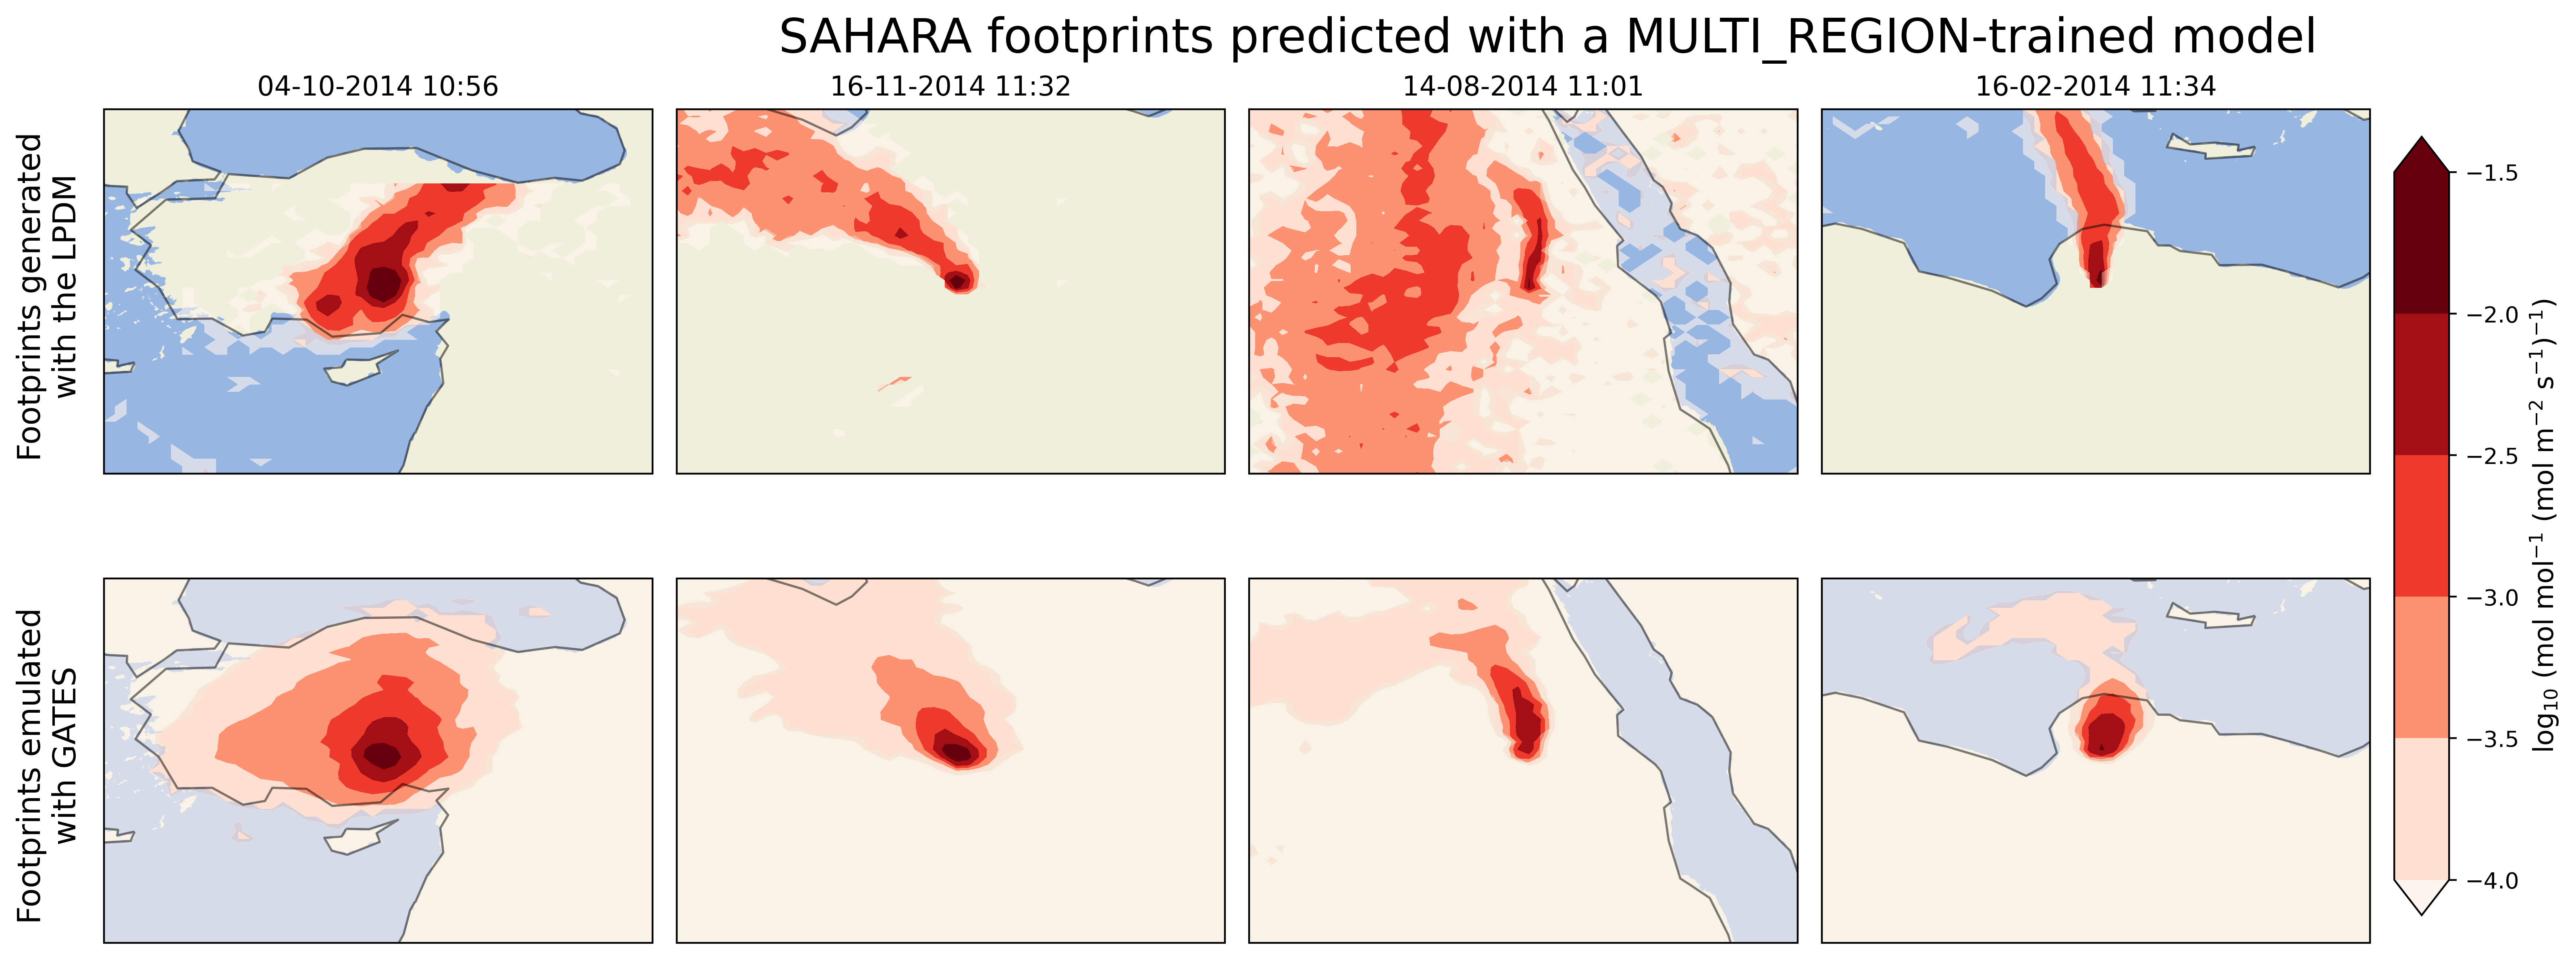

In [19]:
plot_regional_fps("MULTI_REGION", "SAHARA")

In [ ]:
plot_regional_fps("BRAZIL", "CHINA")

In [ ]:
plot_regional_fps("CHINA", "BRAZIL")

In [ ]:
plot_regional_fps("SAHARA", "BRAZIL")

In [ ]:
plot_regional_fps("INDIA", "BRAZIL")

In [ ]:
plot_regional_fps("BRAZIL", "SAHARA")

In [ ]:
plot_regional_fps("CHINA", "SAHARA")

In [ ]:
plot_regional_fps("INDIA", "SAHARA")

In [ ]:
plot_regional_fps("INDIA", "INDIA")

In [ ]:
plot_regional_fps("BRAZIL", "INDIA")

In [ ]:
plot_regional_fps("CHINA", "INDIA")

In [ ]:
plot_regional_fps("SAHARA", "INDIA")

In [ ]:
plot_regional_fps("CHINA", "CHINA")

In [ ]:
plot_regional_fps("BRAZIL", "CHINA")

In [ ]:
plot_regional_fps("INDIA", "CHINA")

In [ ]:
plot_regional_fps("SAHARA", "CHINA")

# Brazil

# China

# India

# Sahara

In [ ]:
preds = xr.open_mfdataset(glob.glob("/mnt/shared/home/kr21883/GATES_LPDM_emulator/model_test_predictions/sahara_model/SAHARA_proper/predictions_SAHARA/predictions_2014_*.nc"))
preds = threshold_fps(preds, threshold=1.75e-5)

In [ ]:
ints_to_plot = random.sample(list(range(len(preds.time.values))), 4)
print(ints_to_plot)

In [ ]:
plot_fp_predictions(preds, idxs_list=ints_to_plot, contour=True, thres=1e-4, fig_title="Sahara footprints predicted with a Sahara-trained model", which_dataspace="original")

# Metrics for whole test set year

In [10]:
# Point to each predictions folder
#pred_dir = "model_test_predictions/india_model/INDIA_proper_train_freq_2_test_freq_25/predictions_BRAZIL"
#pred_dir = "model_test_predictions/sahara_model/SAHARA_proper/predictions_BRAZIL"
#pred_dir = "model_test_predictions/china_model/CHINA_proper/predictions_BRAZIL"

#pred_dir = "model_test_predictions/multi_region_model_341_fullrun/sahara_india_china_brazil_multiregion_proper/predictions_INDIA"

#pred_dir = "model_test_predictions/multi_region_model_341_fullrun/sahara_india_china_brazil_multiregion_proper/predictions_INDIA"

pred_dir = "model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL"

all_results = []

for path in sorted(glob.glob(f"{pred_dir}/predictions_2014_*.nc")):
    print(path)
    preds = xr.open_dataset(path)
    preds = threshold_fps(preds, threshold=1.75e-5)
    metrics = gates_metrics.compute_footprint_metrics(
        preds["fp_original"],
        preds["fp_pred_thres"],
        ignore_mask=preds["fp_nan_mask"]
    )
    month = path.split("_")[-1].replace(".nc", "")  # e.g. "01"
    metrics["month"] = month
    all_results.append(metrics)
    print(f"2014-{month}: {metrics}")

# Summarise as a DataFrame
df = pd.DataFrame(all_results).set_index("month")
print("\n=== Full year summary ===")
print(df)
print("\n=== Annual mean ===")
print(df.drop(columns=["month"], errors="ignore").mean())

out_path = f"{pred_dir}/metrics_summary.txt"
with open(out_path, "w") as f:
    f.write("=== Per-month metrics ===\n")
    f.write(df.to_string())
    f.write("\n\n=== Annual mean ===\n")
    f.write(df.mean().to_string())
print(f"Saved to {out_path}")

model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL/predictions_2014_01.nc
2014-01: {'iou': 0.5145331305164075, 'mse': 8.189522304746788e-07, 'mae': 0.00022758595878258348, 'nmae': 1.0735275745391846, 'corrcoef': 0.6075258002519833, 'corrcoef_log': 0.5476029286404294, 'bias': -3.4065375075442716e-05, 'month': '01'}
model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL/predictions_2014_02.nc
2014-02: {'iou': 0.5145401691686287, 'mse': 1.105241835830384e-06, 'mae': 0.0002395427436567843, 'nmae': 1.0924628973007202, 'corrcoef': 0.6275715323753092, 'corrcoef_log': 0.5683244416124482, 'bias': -3.724029375007376e-05, 'month': '02'}
model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL/predictions_2014_03.nc
2014-03: {'iou': 0.5680877800100118, 'mse': 1.0698468031478114e-06, 'mae': 0.0002563349553383887, 'nmae': 0.9957835078239441, 'corrcoef': 0.6547475037882324, 

# Plotting errors

## Spatial error maps across model type and test domain

The cells below:
- load predictions for each trained model tested on each domain,
- compute time-mean spatial MAE and bias maps,
- plot domain x model grids so you can compare transfer behavior visually.


In [9]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from gates.evaluation.post_processing import threshold_fps


def _pred_dir(model_region, test_region):
    """Return the predictions directory for one trained-model/test-domain pair.

    Parameters
    ----------
    model_region : str
        Model type/training region label (e.g. "BRAZIL", "MULTI_REGION").
    test_region : str
        Test domain label.

    Returns
    -------
    str
        Relative path under project root containing monthly prediction files.
    """
    if model_region == "MULTI_REGION":
        return f"model_test_predictions/multi_region_model_341_fullrun/sahara_india_china_brazil_multiregion_proper/predictions_{test_region}"
    if model_region == "SMALL_MULTI_REGION":
        return f"model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_{test_region}"
    if model_region == "INDIA":
        return f"model_test_predictions/india_model/INDIA_proper_train_freq_2_test_freq_25/predictions_{test_region}"
    return f"model_test_predictions/{model_region.lower()}_model/{model_region}_proper/predictions_{test_region}"


def _coords_from_ds(ds):
    """Extract plotting coordinates from a prediction dataset.

    Supports datasets that store coordinates either as standard `lat`/`lon`
    coordinates or as `lat_coords`/`lon_coords` variables.

    Parameters
    ----------
    ds : xarray.Dataset
        Prediction dataset.

    Returns
    -------
    tuple[xarray.DataArray, xarray.DataArray]
        Longitude and latitude arrays.
    """
    if "lon" in ds.coords:
        lon = ds["lon"]
    else:
        lon = ds["lon_coords"]

    if "lat" in ds.coords:
        lat = ds["lat"]
    else:
        lat = ds["lat_coords"]

    return lon, lat


def load_preds(model_region, test_region, year=2014, threshold=1.75e-5):
    """Load predictions and compute time-mean spatial error maps.

    The function loads all monthly files for a given model/test-domain pair,
    applies footprint thresholding, masks invalid footprint pixels when
    `fp_nan_mask` is present, and computes:
    - `abs_err`: mean over time of `|fp_pred - fp_true|`
    - `bias`: mean over time of `(fp_pred - fp_true)`

    Parameters
    ----------
    model_region : str
        Model type/training region label.
    test_region : str
        Test domain label.
    year : int, optional
        Year to load (default: 2014).
    threshold : float, optional
        Threshold passed to `threshold_fps` (default: 1.75e-5).

    Returns
    -------
    dict | None
        Dictionary with dataset and spatial error maps, or `None` if no files
        were found for that pair.
    """
    pred_dir = _pred_dir(model_region, test_region)
    files = sorted(glob.glob(f"{pred_dir}/predictions_{year}_*.nc"))
    if not files:
        return None

    ds = xr.open_mfdataset(files)
    ds = threshold_fps(ds, threshold=threshold)

    if "fp_pred_thres" in ds:
        pred_var = ds["fp_pred_thres"]
    else:
        pred_var = ds["fp_pred"]

    true_var = ds["fp_original"]

    if "fp_nan_mask" in ds:
        valid = ~ds["fp_nan_mask"].astype(bool)
        true_var = true_var.where(valid)
        pred_var = pred_var.where(valid)

    abs_err_map = np.abs(pred_var - true_var).mean(dim="time", skipna=True)
    bias_map = (pred_var - true_var).mean(dim="time", skipna=True)

    return {
        "dataset": ds,
        "abs_err": abs_err_map,
        "bias": bias_map,
        "n_times": int(ds.sizes.get("time", 0)),
        "pred_dir": pred_dir,
    }


MODEL_TYPES = ["BRAZIL", "CHINA", "INDIA", "SAHARA", "MULTI_REGION", "SMALL_MULTI_REGION"]
TEST_DOMAINS = ["BRAZIL", "CHINA", "INDIA", "SAHARA"]

error_maps = {domain: {} for domain in TEST_DOMAINS}

for domain in TEST_DOMAINS:
    for model_type in MODEL_TYPES:
        result = load_preds(model_type, domain)
        error_maps[domain][model_type] = result
        if result is None:
            print(f"Missing: model={model_type}, domain={domain}")
        else:
            print(
                f"Loaded: model={model_type}, domain={domain}, n_times={result['n_times']}, dir={result['pred_dir']}"
            )

Loaded: model=BRAZIL, domain=BRAZIL, n_times=16495, dir=model_test_predictions/brazil_model/BRAZIL_proper/predictions_BRAZIL
Loaded: model=CHINA, domain=BRAZIL, n_times=16495, dir=model_test_predictions/china_model/CHINA_proper/predictions_BRAZIL
Loaded: model=INDIA, domain=BRAZIL, n_times=16495, dir=model_test_predictions/india_model/INDIA_proper_train_freq_2_test_freq_25/predictions_BRAZIL
Loaded: model=SAHARA, domain=BRAZIL, n_times=16495, dir=model_test_predictions/sahara_model/SAHARA_proper/predictions_BRAZIL
Loaded: model=MULTI_REGION, domain=BRAZIL, n_times=16495, dir=model_test_predictions/multi_region_model_341_fullrun/sahara_india_china_brazil_multiregion_proper/predictions_BRAZIL
Loaded: model=SMALL_MULTI_REGION, domain=BRAZIL, n_times=16495, dir=model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL
Loaded: model=BRAZIL, domain=CHINA, n_times=10550, dir=model_test_predictions/brazil_model/BRAZIL_proper/predictions_CHINA
Loaded: mode

Using fallback loader for metric helpers: unterminated string literal (detected at line 2196) (load_data.py, line 2196)


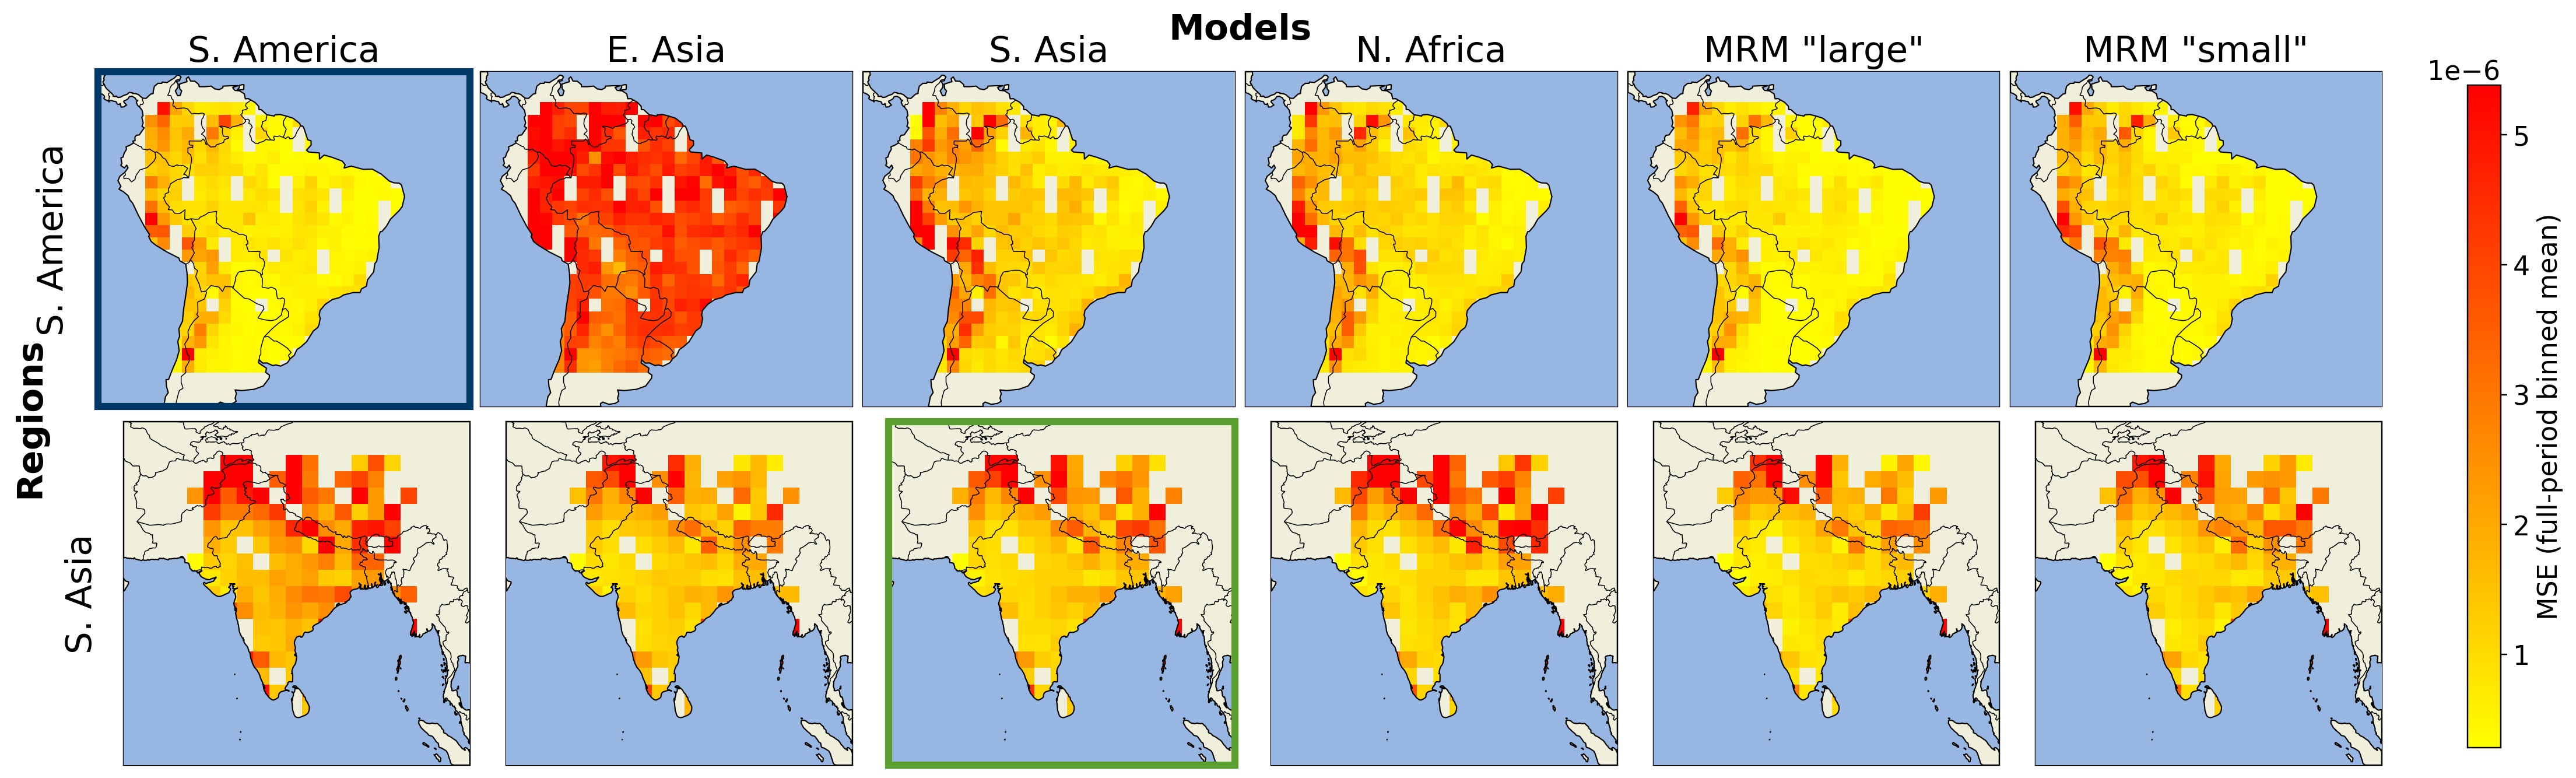

In [11]:
# Megaplot across all models x selected test domains (full period), with selectable metric
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import binned_statistic_2d

from gates.plotting.plotting_predictions import REGION_COLOURS

# Choose one of: "IoU", "MSE", "Corr Coeff", "Logged Corr Coeff"
selected_metric = "MSE"

# Plot controls
degree_bins = 2
min_count = 1
mask_ocean = True
ocean_color = cfeature.COLORS["water"]

fontsize = 20
legend_fontsize = 15

# Color range controls:
# - Set COLOR_RANGE to (vmin, vmax) to force fixed limits.
# - Set COLOR_RANGE = None to use percentile auto-scaling from LOW_PCT/HIGH_PCT.
COLOR_RANGE = None
LOW_PCT = 5
HIGH_PCT = 95

# Row selection: set to None for all rows, or list any subset using either
# canonical names (e.g. "BRAZIL") or display names (e.g. "S. America").
# Example: ROW_SELECTION = ["S. America", "India"]
ROW_SELECTION = ["BRAZIL", "INDIA"]
# ROW_SELECTION = None

# Defaults if these globals are not already defined
_model_defaults = ["BRAZIL", "CHINA", "INDIA", "SAHARA", "MULTI_REGION", "SMALL_MULTI_REGION"]
MODEL_TYPES = list(globals().get("MODEL_TYPES", _model_defaults))
for _m in _model_defaults:
    if _m not in MODEL_TYPES:
        MODEL_TYPES.append(_m)
TEST_DOMAINS = globals().get("TEST_DOMAINS", ["BRAZIL", "CHINA", "INDIA", "SAHARA"])

# Display labels for figure annotations
DISPLAY_NAMES = {
    "BRAZIL": "S. America",
    "CHINA": "E. Asia",
    "INDIA": "S. Asia",
    "SAHARA": "N. Africa",
    "MULTI_REGION": 'MRM "large"',
    "SMALL_MULTI_REGION": 'MRM "small"',
}

# Resolve selected rows while allowing display-name aliases.
_display_to_domain = {v: k for k, v in DISPLAY_NAMES.items() if k in TEST_DOMAINS}
if ROW_SELECTION is None:
    ROW_DOMAINS = list(TEST_DOMAINS)
else:
    requested = []
    for row_name in ROW_SELECTION:
        canonical = _display_to_domain.get(row_name, row_name)
        requested.append(canonical)
    invalid = [d for d in requested if d not in TEST_DOMAINS]
    if invalid:
        valid_rows = TEST_DOMAINS + [DISPLAY_NAMES[d] for d in TEST_DOMAINS]
        raise ValueError(f"Invalid ROW_SELECTION entries: {invalid}. Valid options: {valid_rows}")
    ROW_DOMAINS = requested

if "error_maps" not in globals():
    raise RuntimeError("`error_maps` is missing. Run the predictions-loading cell first.")

try:
    from model.metrics_and_figures import IoU, vcorrcoef
except Exception as import_err:
    candidates = [
        Path.cwd() / "GATES_LPDM_emulator" / "model" / "metrics_and_figures.py",
        Path.cwd() / "model" / "metrics_and_figures.py",
        Path("../model/metrics_and_figures.py").resolve(),
    ]
    metrics_path = next((p for p in candidates if p.exists()), None)
    if metrics_path is None:
        raise FileNotFoundError("Could not locate model/metrics_and_figures.py")

    src = metrics_path.read_text(encoding="utf-8").replace("from model.data.load_data import *", "")
    legacy_ns = {}
    exec(compile(src, str(metrics_path), "exec"), legacy_ns)
    IoU = legacy_ns["IoU"]
    vcorrcoef = legacy_ns["vcorrcoef"]
    print(f"Using fallback loader for metric helpers: {import_err}")


def _metric_per_footprint(true_fps, predictions, metric_name):
    if metric_name == "IoU":
        return 100.0 * IoU(true_fps, predictions, threshold=0, return_mean=False)
    if metric_name == "MSE":
        return np.nanmean((true_fps - predictions) ** 2, axis=(1, 2))
    if metric_name == "Corr Coeff":
        return vcorrcoef(true_fps, predictions, return_mean=False)
    if metric_name == "Logged Corr Coeff":
        with np.errstate(divide="ignore", invalid="ignore"):
            return vcorrcoef(
                np.log10(np.clip(true_fps, 1e-30, None)),
                np.log10(np.clip(predictions, 1e-30, None)),
                return_mean=False,
            )
    raise ValueError(f"Unsupported metric: {metric_name}")


def _binned_pair_map(item, metric_name, degree_bins=2, min_count=1):
    ds_ref = item["dataset"]
    true_fps = ds_ref["fp_original"].values
    predictions = ds_ref["fp_pred_thres"].values if "fp_pred_thres" in ds_ref else ds_ref["fp_pred"].values

    lat_coords = np.asarray(ds_ref["lat_coords"].values)
    lon_coords = np.asarray(ds_ref["lon_coords"].values)

    lat_c = lat_coords.shape[1] // 2
    lon_c = lon_coords.shape[1] // 2
    release_lats = lat_coords[:, lat_c]
    release_lons = lon_coords[:, lon_c]

    lat_min, lat_max = float(np.nanmin(lat_coords)), float(np.nanmax(lat_coords))
    lon_min, lon_max = float(np.nanmin(lon_coords)), float(np.nanmax(lon_coords))

    lat_bins = np.arange(np.floor(lat_min), np.ceil(lat_max) + degree_bins, degree_bins)
    lon_bins = np.arange(np.floor(lon_min), np.ceil(lon_max) + degree_bins, degree_bins)
    if lat_bins.size < 2:
        lat_bins = np.array([lat_min - 0.5, lat_max + 0.5])
    if lon_bins.size < 2:
        lon_bins = np.array([lon_min - 0.5, lon_max + 0.5])

    per_fp_metric = _metric_per_footprint(true_fps, predictions, metric_name)

    metric_map, lat_edges, lon_edges, _ = binned_statistic_2d(
        release_lats,
        release_lons,
        per_fp_metric,
        statistic="mean",
        bins=[lat_bins, lon_bins],
    )
    counts, _, _, _ = binned_statistic_2d(
        release_lats,
        release_lons,
        np.ones_like(release_lats),
        statistic="sum",
        bins=[lat_bins, lon_bins],
    )

    metric_map = np.where(counts >= min_count, metric_map, np.nan)

    return {
        "metric_map": metric_map,
        "counts": counts,
        "lat_edges": lat_edges,
        "lon_edges": lon_edges,
        "extent": (lon_min, lon_max, lat_min, lat_max),
    }


binned_maps = {domain: {} for domain in ROW_DOMAINS}
all_values = []

for domain in ROW_DOMAINS:
    domain_maps = error_maps.get(domain, {})
    for model_type in MODEL_TYPES:
        item = domain_maps.get(model_type)
        if item is None:
            binned_maps[domain][model_type] = None
            continue

        pair_map = _binned_pair_map(
            item,
            metric_name=selected_metric,
            degree_bins=degree_bins,
            min_count=min_count,
        )
        binned_maps[domain][model_type] = pair_map
        vals = pair_map["metric_map"]
        vals = vals[np.isfinite(vals)]
        if vals.size > 0:
            all_values.append(vals)

if not all_values:
    raise RuntimeError("No finite values available for plotting.")

all_values = np.concatenate(all_values)

if selected_metric == "MSE":
    cmap = "autumn_r"
else:
    cmap = "autumn"

if COLOR_RANGE is not None:
    vmin, vmax = COLOR_RANGE
else:
    if selected_metric == "MSE":
        vmin = float(np.nanpercentile(all_values, LOW_PCT))
        vmax = float(np.nanpercentile(all_values, HIGH_PCT))
    else:
        vmin = float(np.nanpercentile(all_values, LOW_PCT))
        vmax = float(np.nanpercentile(all_values, HIGH_PCT))

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

nrows = len(ROW_DOMAINS)
ncols = len(MODEL_TYPES)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3.3 * ncols, 2.9 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=220,
    constrained_layout=True,
)

if nrows == 1:
    axes = np.expand_dims(axes, axis=0)

mesh = None
for r, domain in enumerate(ROW_DOMAINS):
    for c, model_type in enumerate(MODEL_TYPES):
        ax = axes[r, c]
        pair_map = binned_maps[domain][model_type]

        ax.add_feature(cfeature.LAND, zorder=0)
        ax.coastlines(linewidth=0.7, zorder=4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=4)

        if pair_map is None:
            ax.set_title("missing", fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        lon_min, lon_max, lat_min, lat_max = pair_map["extent"]
        ax.set_extent((lon_min, lon_max, lat_min, lat_max), crs=ccrs.PlateCarree())

        mesh = ax.pcolormesh(
            pair_map["lon_edges"],
            pair_map["lat_edges"],
            pair_map["metric_map"],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            shading="auto",
            zorder=2,
        )

        if mask_ocean:
            ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, edgecolor="none", zorder=3)

        # Use a rectangle in axes coordinates for visually uniform highlight thickness.
        highlight_this_panel = model_type == domain
        highlight_colour = REGION_COLOURS.get(domain, "black")
        if highlight_this_panel:
            frame = mpatches.Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                fill=False,
                edgecolor=highlight_colour,
                linewidth=4.0,
                zorder=10,
                joinstyle="miter",
                capstyle="projecting",
                clip_on=False,
            )
            ax.add_patch(frame)

        if r == 0:
            ax.set_title(DISPLAY_NAMES.get(model_type, model_type), fontsize=fontsize)
        if c == 0:
            ax.text(
                -0.12,
                0.5,
                DISPLAY_NAMES.get(domain, domain),
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=fontsize,
            )

if mesh is not None:
    cbar = fig.colorbar(mesh, ax=axes, shrink=0.95, pad=0.02)
    cbar.set_label(f"{selected_metric} (full-period binned mean)", fontsize=legend_fontsize)
    cbar.ax.tick_params(labelsize=legend_fontsize)
    cbar.ax.yaxis.get_offset_text().set_fontsize(legend_fontsize)

# Shared figure headers spanning all columns and rows.
fig.canvas.draw()
grid_left = min(ax.get_position().x0 for ax in axes.flat)
grid_right = max(ax.get_position().x1 for ax in axes.flat)
grid_bottom = min(ax.get_position().y0 for ax in axes.flat)
grid_top = max(ax.get_position().y1 for ax in axes.flat)

fig.text(
    (grid_left + grid_right) / 2,
    min(0.995, grid_top + 0.03),
    "Models",
    ha="center",
    va="bottom",
    fontsize=fontsize,
    fontweight="bold",
)
fig.text(
    max(0.0, grid_left - 0.11),
    (grid_bottom + grid_top) / 2,
    "Regions",
    rotation=90,
    ha="center",
    va="center",
    fontsize=fontsize,
    fontweight="bold",
)

#fig.suptitle(
#    f"Megaplot: {selected_metric} across model type (cols) and test domain (rows)\n"
#    f"degree_bins={degree_bins}, min_count={min_count}, mask_ocean={mask_ocean}",
#    fontsize=13,
#)
plt.show()
fig.savefig("model_test_predictions/plots/mse_subset_clip_341.pdf", dpi=300, bbox_inches="tight")

# EXPERIMENTAL: Quantifying distances

In [7]:
# Region distance score model (inputs + footprint-derived features) and new-sample scoring
import numpy as np
import pandas as pd


def _extract_sample_features(ds, threshold=1.75e-5):
    """Extract per-sample features from one dataset for domain-distance modeling."""
    fp = np.asarray(ds["fp_original"].values, dtype=np.float64)  # (time, lat, lon)
    n = fp.shape[0]

    lat_coords = np.asarray(ds["lat_coords"].values, dtype=np.float64)  # (time, lat)
    lon_coords = np.asarray(ds["lon_coords"].values, dtype=np.float64)  # (time, lon)

    eps = 1e-30
    mass = np.nansum(fp, axis=(1, 2)) + eps
    fp_lat_marg = np.nansum(fp, axis=2)  # (time, lat)
    fp_lon_marg = np.nansum(fp, axis=1)  # (time, lon)

    centroid_lat = np.nansum(fp_lat_marg * lat_coords, axis=1) / mass
    centroid_lon = np.nansum(fp_lon_marg * lon_coords, axis=1) / mass

    var_lat = np.nansum(fp_lat_marg * (lat_coords - centroid_lat[:, None]) ** 2, axis=1) / mass
    var_lon = np.nansum(fp_lon_marg * (lon_coords - centroid_lon[:, None]) ** 2, axis=1) / mass

    release_lat = lat_coords[:, lat_coords.shape[1] // 2]
    release_lon = lon_coords[:, lon_coords.shape[1] // 2]

    base_features = {
        "release_lat": release_lat,
        "release_lon": release_lon,
        "fp_log_mass": np.log10(mass),
        "fp_centroid_lat": centroid_lat,
        "fp_centroid_lon": centroid_lon,
        "fp_spread_lat": np.sqrt(np.maximum(var_lat, 0.0)),
        "fp_spread_lon": np.sqrt(np.maximum(var_lon, 0.0)),
        "fp_sparsity": np.mean(fp > threshold, axis=(1, 2)),
        "fp_p95": np.nanpercentile(fp, 95, axis=(1, 2)),
    }

    # Optional additional predictors (meteorology/topography/etc) if present in dataset
    excluded = {
        "fp_original", "fp_pred", "fp_pred_thres", "fp_transformed", "fp_transformed_pred",
        "fp_nan_mask", "lat_coords", "lon_coords", "lat", "lon", "idx", "time",
    }

    for var in ds.data_vars:
        if var in excluded:
            continue
        arr = ds[var]
        if "time" not in arr.dims:
            continue

        vals = np.asarray(arr.values, dtype=np.float64)
        if vals.shape[0] != n:
            continue

        if vals.ndim == 1:
            base_features[f"{var}"] = vals
        else:
            reduce_axes = tuple(range(1, vals.ndim))
            base_features[f"{var}_mean"] = np.nanmean(vals, axis=reduce_axes)
            base_features[f"{var}_std"] = np.nanstd(vals, axis=reduce_axes)

    feat_names = list(base_features.keys())
    X = np.column_stack([base_features[k] for k in feat_names])

    # Clean invalid values column-wise
    X = np.where(np.isfinite(X), X, np.nan)
    col_med = np.nanmedian(X, axis=0)
    col_med = np.where(np.isfinite(col_med), col_med, 0.0)
    inds = np.where(~np.isfinite(X))
    X[inds] = col_med[inds[1]]

    return X, feat_names


def _fit_region_distance_model(error_maps, model_for_features="MULTI_REGION", domains=None, max_samples_per_domain=4000):
    """Fit a standardized Gaussian model per domain for Mahalanobis distance scoring."""
    if domains is None:
        domains = list(error_maps.keys())

    domain_X = {}
    feat_names_ref = None

    for domain in domains:
        item = error_maps[domain][model_for_features]
        if item is None:
            continue

        X, feat_names = _extract_sample_features(item["dataset"])
        if feat_names_ref is None:
            feat_names_ref = feat_names
        elif feat_names != feat_names_ref:
            raise ValueError("Feature mismatch across domains; ensure consistent dataset schema.")

        if X.shape[0] > max_samples_per_domain:
            idx = np.random.default_rng(0).choice(X.shape[0], size=max_samples_per_domain, replace=False)
            X = X[idx]

        domain_X[domain] = X

    if not domain_X:
        raise RuntimeError("No domain datasets available to fit distance model.")

    # Global standardization
    all_X = np.vstack(list(domain_X.values()))
    mu_g = np.mean(all_X, axis=0)
    sd_g = np.std(all_X, axis=0)
    sd_g = np.where(sd_g < 1e-12, 1.0, sd_g)

    region_models = {}
    for domain, X in domain_X.items():
        Xz = (X - mu_g) / sd_g
        mu = np.mean(Xz, axis=0)
        cov = np.cov(Xz, rowvar=False)
        reg = 1e-3 * np.eye(cov.shape[0])
        cov_inv = np.linalg.pinv(cov + reg)
        region_models[domain] = {
            "mu": mu,
            "cov_inv": cov_inv,
            "Xz": Xz,
        }

    return {
        "domains": list(region_models.keys()),
        "feature_names": feat_names_ref,
        "global_mu": mu_g,
        "global_sd": sd_g,
        "regions": region_models,
    }


def _mahalanobis_to_region(Xz, mu, cov_inv):
    d = Xz - mu[None, :]
    return np.sqrt(np.einsum("ij,jk,ik->i", d, cov_inv, d))


def pairwise_region_distance_matrix(model):
    """Symmetric region distance: average cross-domain Mahalanobis distances."""
    domains = model["domains"]
    out = pd.DataFrame(index=domains, columns=domains, dtype=float)

    for d1 in domains:
        X1 = model["regions"][d1]["Xz"]
        for d2 in domains:
            m2 = model["regions"][d2]
            d12 = _mahalanobis_to_region(X1, m2["mu"], m2["cov_inv"]).mean()

            X2 = model["regions"][d2]["Xz"]
            m1 = model["regions"][d1]
            d21 = _mahalanobis_to_region(X2, m1["mu"], m1["cov_inv"]).mean()

            out.loc[d1, d2] = 0.5 * (d12 + d21)

    return out


def score_new_samples(ds_new, model, reference_domain=None):
    """Distance to each region + percentile-vs-reference for OOD-style interpretation."""
    X_new, feat_names_new = _extract_sample_features(ds_new)
    if feat_names_new != model["feature_names"]:
        raise ValueError("New sample features do not match fitted model features.")

    Xz = (X_new - model["global_mu"]) / model["global_sd"]

    scores = {}
    for domain in model["domains"]:
        m = model["regions"][domain]
        scores[f"dist_to_{domain}"] = _mahalanobis_to_region(Xz, m["mu"], m["cov_inv"])

    df = pd.DataFrame(scores)

    if reference_domain is not None and reference_domain in model["domains"]:
        ref_m = model["regions"][reference_domain]
        ref_self = _mahalanobis_to_region(ref_m["Xz"], ref_m["mu"], ref_m["cov_inv"])
        ref_new = _mahalanobis_to_region(Xz, ref_m["mu"], ref_m["cov_inv"])
        df["ref_domain"] = reference_domain
        df["ref_distance"] = ref_new
        df["ref_percentile"] = np.searchsorted(np.sort(ref_self), ref_new, side="right") / len(ref_self)

    # Add nearest-region summary
    dist_cols = [c for c in df.columns if c.startswith("dist_to_")]
    dist_vals = df[dist_cols].values
    nearest_idx = np.argmin(dist_vals, axis=1)
    df["nearest_region"] = [dist_cols[i].replace("dist_to_", "") for i in nearest_idx]
    df["nearest_distance"] = dist_vals[np.arange(len(df)), nearest_idx]

    return df


# Fit model using one consistent source of predictors per domain
region_dist_model = _fit_region_distance_model(
    error_maps,
    model_for_features="MULTI_REGION",
    domains=TEST_DOMAINS,
    max_samples_per_domain=4000,
)

pairwise_dist = pairwise_region_distance_matrix(region_dist_model)
print("Pairwise region distance matrix (lower = more similar):")
print(pairwise_dist.round(3))

# Example: score new samples from BRAZIL domain
example_ds = error_maps["BRAZIL"]["MULTI_REGION"]["dataset"].isel(time=slice(0, 20))
new_scores = score_new_samples(example_ds, region_dist_model, reference_domain="BRAZIL")

print("\nExample new-sample scores (first 10 rows):")
print(new_scores.head(10))

print("\nFeature count used:", len(region_dist_model["feature_names"]))
print("First 12 feature names:", region_dist_model["feature_names"][:12])

Pairwise region distance matrix (lower = more similar):
        BRAZIL   CHINA   INDIA  SAHARA
BRAZIL   2.664  15.958  18.938   9.145
CHINA   15.958   2.651   5.111   8.456
INDIA   18.938   5.111   2.676   8.874
SAHARA   9.145   8.456   8.874   2.551

Example new-sample scores (first 10 rows):
   dist_to_BRAZIL  dist_to_CHINA  dist_to_INDIA  dist_to_SAHARA ref_domain  \
0        3.475191      13.650321      21.405711        6.977965     BRAZIL   
1        2.309532      13.179744      20.942390        6.923141     BRAZIL   
2        2.103765      12.915531      21.420396        7.589699     BRAZIL   
3        1.652570      13.732786      21.993216        7.552706     BRAZIL   
4        1.673515      13.610681      21.651632        7.731098     BRAZIL   
5        1.869581      12.994691      21.628364        7.763324     BRAZIL   
6        1.911133      13.706708      21.765585        7.972443     BRAZIL   
7        2.328750      13.691332      22.268806        8.660129     BRAZIL   
8  